# 01a · Dataset Viewer — CrossDocked + PDBbind

Browser for the two datasets VoxBind uses. **Both render top-to-bottom** — **Part A** is CrossDocked, **Part B** is PDBbind. Each part has: stats · select a complex + 3D view · single-example density · NGLView (optional). Set the per-dataset knobs in the setup cell.

| Part | structures | density source |
|---|---|---|
| **A · CrossDocked** | `data_{train,test}.pt` + `crossdocked_pocket10/` | 2Fo-Fc CCP4 map — only downloaded PDBs (e.g. `14gs`) |
| **B · PDBbind** | `pdbbind/index.csv` + `structures/pbpp-2020/` | `pdbbind/voxels_v{1,2,3}/density/{pid}.npy` |

*(Supersedes the former `01a_dataset`, `01d_dataset_pdbbind`, and `01b_data_density`.)*

In [1]:
# ── setup: imports, paths, shared helpers ───────────────────────────────────
import gemmi                 # before torch (avoids silent _load_grid failures)
import os, sys, math, json
sys.path.insert(0, os.path.abspath(".."))
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook_connected"     # embed plotly without launching a browser

# ─────────────────────────── per-dataset knobs ──────────────────────────────
CROSSDOCKED_PDB = "14gs"            # density needs a downloaded CCP4 (see notebook/data/*.ccp4)
PDBBIND_PDB     = "10gs"
DENSITY_VERSION = "v3"             # pdbbind crop normalization: v1 | v2 | v3
# ─────────────────────────────────────────────────────────────────────────────

DATA_DIR    = Path("..") / "voxbind" / "dataset" / "data"
PDBBIND_DIR = DATA_DIR / "pdbbind"
CCP4_DIR    = Path("data")          # notebook/data/{pid}.ccp4

ELEM_COLOR = {"C": "#808080", "N": "#3498db", "O": "#e74c3c", "S": "#f1c40f",
              "F": "#2ecc71", "Cl": "#27ae60", "Br": "#8e44ad", "P": "#e67e22",
              "I": "#34495e", "H": "#ffffff"}

def structure_view(poc_xyz, poc_elems, lig_xyz, lig_elems, title):
    # interactive 3D plotly: pocket (grey) + ligand (by element)
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(x=poc_xyz[:, 0], y=poc_xyz[:, 1], z=poc_xyz[:, 2], mode="markers",
                               marker=dict(size=3, color="lightgrey", opacity=0.85), name=f"Pocket ({len(poc_elems)})"))
    la = np.array(lig_elems)
    for e in sorted(set(lig_elems)):
        if e == "H":
            continue
        m = la == e
        fig.add_trace(go.Scatter3d(x=lig_xyz[m, 0], y=lig_xyz[m, 1], z=lig_xyz[m, 2], mode="markers",
                                   marker=dict(size=6, color=ELEM_COLOR.get(e, "purple")), name=f"Ligand {e} ({int(m.sum())})"))
    fig.update_layout(title=title, width=820, height=650, legend=dict(itemsizing="constant"),
                      scene=dict(xaxis_title="x (Å)", yaxis_title="y (Å)", zaxis_title="z (Å)", aspectmode="data"))
    return fig

def nglview_surface(f0, f1):
    # optional NGLView: protein surface + ligand ball+stick; degrades gracefully
    try:
        import nglview as nv
        from IPython.display import display
        v = nv.NGLWidget(height="550px", width="650px")
        v.add_component(str(f0)); v.clear_representations(component=0)
        v.add_representation("surface", component=0, opacity=0.4, color="electrostatic", surfaceType="av")
        v.add_component(str(f1)); v.clear_representations(component=1)
        v.add_representation("ball+stick", component=1, colorScheme="element")
        v.center(); display(v)
    except Exception as e:
        print("NGLView unavailable / non-interactive context:", repr(e))

print(f"CrossDocked PDB = {CROSSDOCKED_PDB} | PDBbind PDB = {PDBBIND_PDB} (density {DENSITY_VERSION})")

CrossDocked PDB = 14gs | PDBbind PDB = 10gs (density v3)


# Part A — CrossDocked

A1 stats · A2 select + 3D view · A3 single-example 2Fo-Fc density · A4 NGLView.

Train / Test / Total : 99,981 / 100 / 100,081


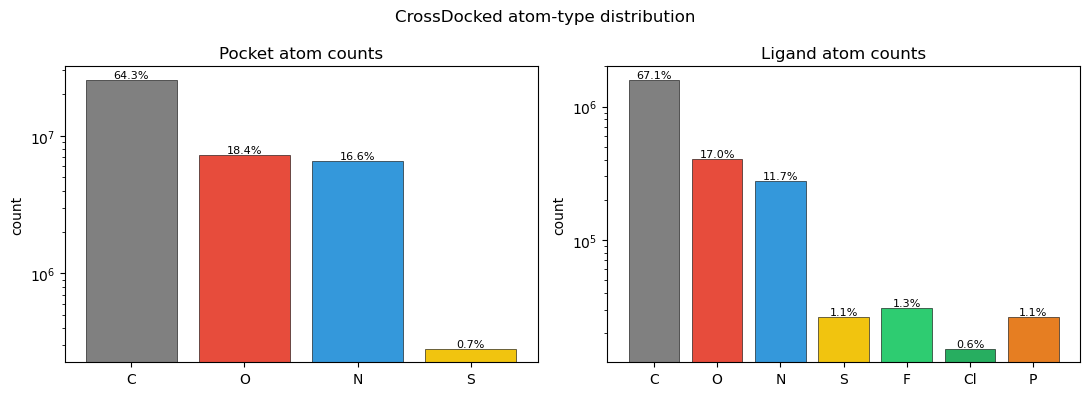

In [2]:
# ── A1 · stats — atom-type distribution over the full dataset ────────────────
import torch
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED, N_POCKET_ELEMENTS, N_LIGAND_ELEMENTS
IDX_TO_ELEM = {v: k for k, v in ELEMENTS_HASH_CROSSDOCKED.items()}
cd_data = {"train": torch.load(DATA_DIR / "data_train.pt", weights_only=False),
           "test":  torch.load(DATA_DIR / "data_test.pt",  weights_only=False)}
_all = cd_data["train"] + cd_data["test"]
poc_counts = torch.bincount(torch.cat([p["atoms_channel"] for p, l in _all]).long(),
                            minlength=N_POCKET_ELEMENTS)[:N_POCKET_ELEMENTS].numpy()
lig_counts = torch.bincount(torch.cat([l["atoms_channel"] for p, l in _all]).long(),
                            minlength=N_LIGAND_ELEMENTS)[:N_LIGAND_ELEMENTS].numpy()
poc_names = [IDX_TO_ELEM[i] for i in range(N_POCKET_ELEMENTS)]
lig_names = [IDX_TO_ELEM[i] for i in range(N_LIGAND_ELEMENTS)]
print(f"Train / Test / Total : {len(cd_data['train']):,} / {len(cd_data['test']):,} / {len(_all):,}")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, names, counts, t in ((axes[0], poc_names, poc_counts, "Pocket"),
                             (axes[1], lig_names, lig_counts, "Ligand")):
    bars = ax.bar(names, counts, color=[ELEM_COLOR[e] for e in names], edgecolor="black", linewidth=0.4)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{c / counts.sum() * 100:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.set_yscale("log"); ax.set_title(f"{t} atom counts"); ax.set_ylabel("count")
fig.suptitle("CrossDocked atom-type distribution"); fig.tight_layout(); plt.show()

In [3]:
# ── A2 · select complex by PDB ID + 3D structure view ────────────────────────
def _pdb_of(s): return s.split("/")[1].split("_")[0].lower()
hit = None
for split in ("test", "train"):
    for poc, lig in cd_data[split]:
        if _pdb_of(poc["id"]) == CROSSDOCKED_PDB.lower():
            hit = (split, poc, lig); break
    if hit:
        break
if hit is None:
    raise ValueError(f"{CROSSDOCKED_PDB!r} not found in CrossDocked")
split, poc, lig = hit
cd_poc_xyz = poc["coords"].numpy(); cd_poc_elems = [IDX_TO_ELEM.get(int(c), "?") for c in poc["atoms_channel"].numpy()]
cd_lig_xyz = lig["coords"].numpy(); cd_lig_elems = [IDX_TO_ELEM.get(int(c), "?") for c in lig["atoms_channel"].numpy()]
cd_title = f"{CROSSDOCKED_PDB.upper()} · CrossDocked ({split})"
cd_ngl = (DATA_DIR / "crossdocked_pocket10" / poc["id"], DATA_DIR / "crossdocked_pocket10" / lig["id"])
print(f"{cd_title} | pocket {poc['id']} ({len(cd_poc_elems)} atoms) | ligand {len(cd_lig_elems)} atoms")
structure_view(cd_poc_xyz, cd_poc_elems, cd_lig_xyz, cd_lig_elems, cd_title).show()

14GS · CrossDocked (test) | pocket GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb (255 atoms) | ligand 22 atoms


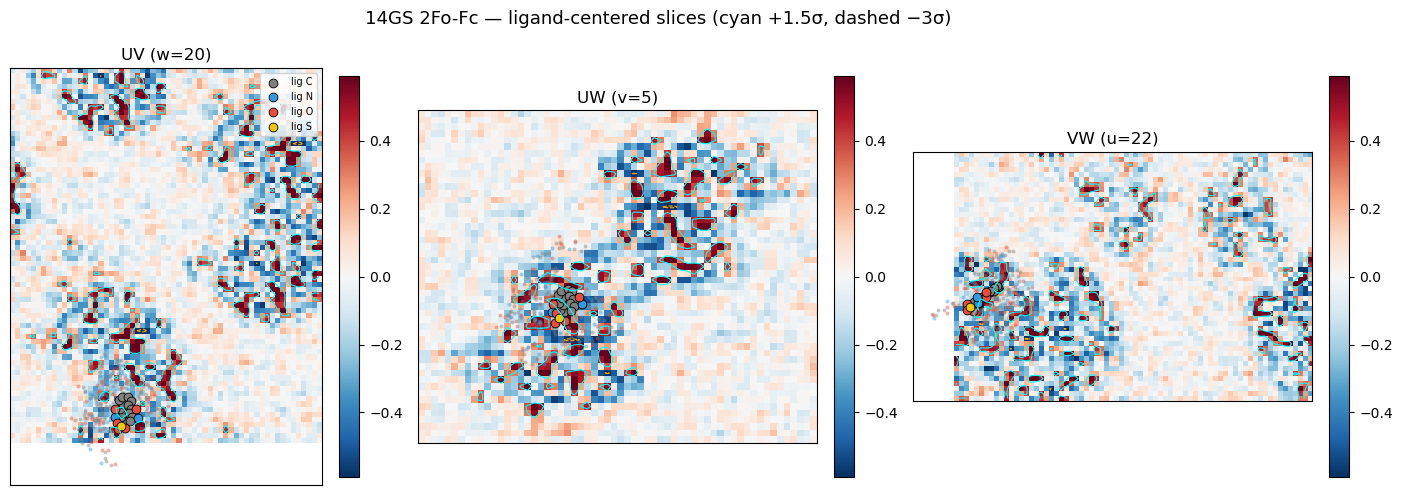

In [4]:
# ── A3 · single example — 2Fo-Fc density (CCP4) ──────────────────────────────
ccp4 = CCP4_DIR / f"{CROSSDOCKED_PDB.lower()}.ccp4"
if not ccp4.exists():
    print(f"No CCP4 map at {ccp4} — the 2Fo-Fc density view needs a downloaded map "
          f"(00a_data_density_download.py). Stats + structure above still work.")
else:
    m = gemmi.read_ccp4_map(str(ccp4)); m.setup(float("nan"))
    grid = m.grid; arr = np.array(grid, dtype=np.float32); cell = grid.unit_cell
    nu, nv, nw = arr.shape; mean = float(np.nanmean(arr)); sigma = float(np.nanstd(arr))

    def cart_to_grid(xyz):
        out = np.zeros_like(xyz, dtype=float)
        for i, (x, y, z) in enumerate(xyz):
            f = cell.fractionalize(gemmi.Position(float(x), float(y), float(z)))
            out[i] = [f.x * nu, f.y * nv, f.z * nw]
        return out

    pg, lg = cart_to_grid(cd_poc_xyz), cart_to_grid(cd_lig_xyz)
    cen = lg.mean(0)
    ci, cj, ck = (int(np.clip(round(cen[d]), 0, [nu, nv, nw][d] - 1)) for d in range(3))
    vmin, vmax = mean - 3 * sigma, mean + 3 * sigma
    pe, le = np.array(cd_poc_elems), np.array(cd_lig_elems)
    specs = [(f"UV (w={ck})", arr[:, :, ck], (pg[:, 0], pg[:, 1]), (lg[:, 0], lg[:, 1])),
             (f"UW (v={cj})", arr[:, cj, :], (pg[:, 0], pg[:, 2]), (lg[:, 0], lg[:, 2])),
             (f"VW (u={ci})", arr[ci, :, :], (pg[:, 1], pg[:, 2]), (lg[:, 1], lg[:, 2]))]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (t, slc, (px, py), (lx, ly)) in zip(axes, specs):
        im = ax.imshow(slc.T, origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="equal")
        ax.contour(slc.T, levels=[mean + 1.5 * sigma], colors=["cyan"], linewidths=0.8)
        ax.contour(slc.T, levels=[mean - 3.0 * sigma], colors=["orange"], linewidths=0.8, linestyles="dashed")
        for e in sorted(set(cd_poc_elems)):
            mk = pe == e; ax.scatter(np.array(px)[mk], np.array(py)[mk], c=ELEM_COLOR.get(e, "purple"), s=8, alpha=0.45, linewidths=0)
        for e in sorted(set(cd_lig_elems)):
            mk = le == e; ax.scatter(np.array(lx)[mk], np.array(ly)[mk], c=ELEM_COLOR.get(e, "purple"), s=40, edgecolors="black", linewidths=0.6, label=f"lig {e}")
        ax.set_title(t); ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    axes[0].legend(fontsize=7, loc="upper right")
    plt.suptitle(f"{CROSSDOCKED_PDB.upper()} 2Fo-Fc — ligand-centered slices (cyan +1.5σ, dashed −3σ)", fontsize=13)
    plt.tight_layout(); plt.show()

    R = 18
    i0, i1 = max(0, ci - R), min(nu, ci + R); j0, j1 = max(0, cj - R), min(nv, cj + R); k0, k1 = max(0, ck - R), min(nw, ck + R)
    sub = arr[i0:i1, j0:j1, k0:k1]; br = math.radians(cell.beta)
    Fi, Fj, Fk = np.meshgrid(np.arange(i0, i1) / nu, np.arange(j0, j1) / nv, np.arange(k0, k1) / nw, indexing="ij")
    Xc = cell.a * Fi + cell.c * math.cos(br) * Fk; Yc = cell.b * Fj; Zc = cell.c * math.sin(br) * Fk
    tr = [go.Isosurface(x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(), value=sub.ravel(),
                        isomin=mean + 1.5 * sigma, isomax=mean + 1.5 * sigma, surface_count=1,
                        colorscale=[[0, "blue"], [1, "blue"]], showscale=False, opacity=0.30, name="+1.5σ",
                        caps=dict(x_show=False, y_show=False, z_show=False))]
    for e in sorted(set(cd_lig_elems)):
        mk = le == e
        tr.append(go.Scatter3d(x=cd_lig_xyz[mk, 0], y=cd_lig_xyz[mk, 1], z=cd_lig_xyz[mk, 2], mode="markers",
                               marker=dict(size=6, color=ELEM_COLOR.get(e, "purple"), line=dict(color="black", width=1)), name=f"lig {e}"))
    go.Figure(tr).update_layout(title=f"{CROSSDOCKED_PDB.upper()} 2Fo-Fc · +1.5σ isosurface + ligand", width=820, height=650,
                                scene=dict(xaxis_title="X (Å)", yaxis_title="Y (Å)", zaxis_title="Z (Å)", aspectmode="data")).show()

In [5]:
# ── A4 · NGLView surface (optional) ──────────────────────────────────────────
nglview_surface(*cd_ngl)

NGLWidget()

# Part B — PDBbind

B1 stats · B2 select + 3D view · B3 single-example density crop · B4 NGLView.

Index rows / on-disk : 19,443 / 5,316
pK mean ± std        : 6.39 ± 1.95   range [2.00, 11.92]
new_split            : {'train': 2999, 'test': 1439, 'val': 626, nan: 252}


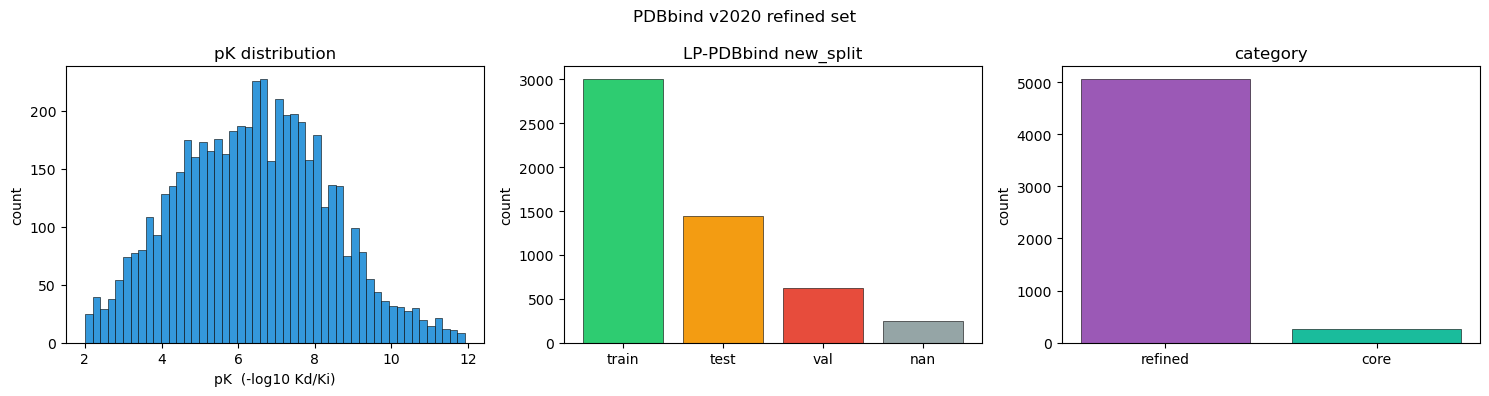

In [6]:
# ── B1 · stats — pK + split + category distributions ─────────────────────────
import pandas as pd
pb_df = pd.read_csv(PDBBIND_DIR / "index.csv")
ds = pb_df[pb_df.has_struct].copy()
print(f"Index rows / on-disk : {len(pb_df):,} / {len(ds):,}")
print(f"pK mean ± std        : {ds['pK'].mean():.2f} ± {ds['pK'].std():.2f}   range [{ds['pK'].min():.2f}, {ds['pK'].max():.2f}]")
print(f"new_split            : {ds['new_split'].value_counts(dropna=False).to_dict()}")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(ds["pK"].dropna(), bins=50, color="#3498db", edgecolor="black", linewidth=0.4)
axes[0].set_xlabel("pK  (-log10 Kd/Ki)"); axes[0].set_ylabel("count"); axes[0].set_title("pK distribution")
sc = ds["new_split"].value_counts(dropna=False)
axes[1].bar(sc.index.astype(str), sc.values, color=["#2ecc71", "#f39c12", "#e74c3c", "#95a5a6"][:len(sc)], edgecolor="black", linewidth=0.4)
axes[1].set_title("LP-PDBbind new_split"); axes[1].set_ylabel("count")
cc = ds["category"].value_counts()
axes[2].bar(cc.index, cc.values, color=["#9b59b6", "#1abc9c", "#7f8c8d"][:len(cc)], edgecolor="black", linewidth=0.4)
axes[2].set_title("category"); axes[2].set_ylabel("count")
fig.suptitle("PDBbind v2020 refined set"); fig.tight_layout(); plt.show()

In [7]:
# ── B2 · select complex by PDB ID + 3D structure view ────────────────────────
def load_pdb_atoms(path):
    coords, elems = [], []
    for ln in open(path):
        if ln.startswith(("ATOM  ", "HETATM")):
            coords.append([float(ln[30:38]), float(ln[38:46]), float(ln[46:54])])
            el = ln[76:78].strip().capitalize() or "".join(c for c in ln[12:16] if c.isalpha())[:1].upper()
            elems.append(el)
    return np.array(coords), elems

def load_sdf_atoms(path):
    L = open(path).readlines(); n = int(L[3][:3]); coords, elems = [], []
    for i in range(n):
        ln = L[4 + i]; coords.append([float(ln[0:10]), float(ln[10:20]), float(ln[20:30])]); elems.append(ln[31:34].strip())
    return np.array(coords), elems

pid = PDBBIND_PDB.lower()
r = pb_df[pb_df.pdb_id == pid]
if r.empty or not r.iloc[0].has_struct:
    raise ValueError(f"{pid!r} not on disk in PDBbind")
r = r.iloc[0]; cdir = PDBBIND_DIR / "structures" / "pbpp-2020" / pid
pb_poc_xyz, pb_poc_elems = load_pdb_atoms(cdir / f"{pid}_pocket.pdb")
pb_lig_xyz, pb_lig_elems = load_sdf_atoms(cdir / f"{pid}_ligand.sdf")
keep = np.array([e != "H" for e in pb_poc_elems])                       # pocket heavy atoms only
pb_poc_xyz, pb_poc_elems = pb_poc_xyz[keep], [e for e, k in zip(pb_poc_elems, keep) if k]
pb_title = f"{pid.upper()} · PDBbind · pK={r['pK']:.2f} · {r['category']} · split={r['new_split']}"
pb_ngl = (cdir / f"{pid}_protein.pdb", cdir / f"{pid}_ligand.sdf")
print(f"{pb_title} | pocket {len(pb_poc_elems)} heavy | ligand {len(pb_lig_elems)} atoms")
structure_view(pb_poc_xyz, pb_poc_elems, pb_lig_xyz, pb_lig_elems, pb_title).show()

10GS · PDBbind · pK=6.40 · refined · split=train | pocket 431 heavy | ligand 61 atoms


v3 crop (64, 64, 64)  range [-0.022, +0.050]  mean -0.0005  std 0.0085


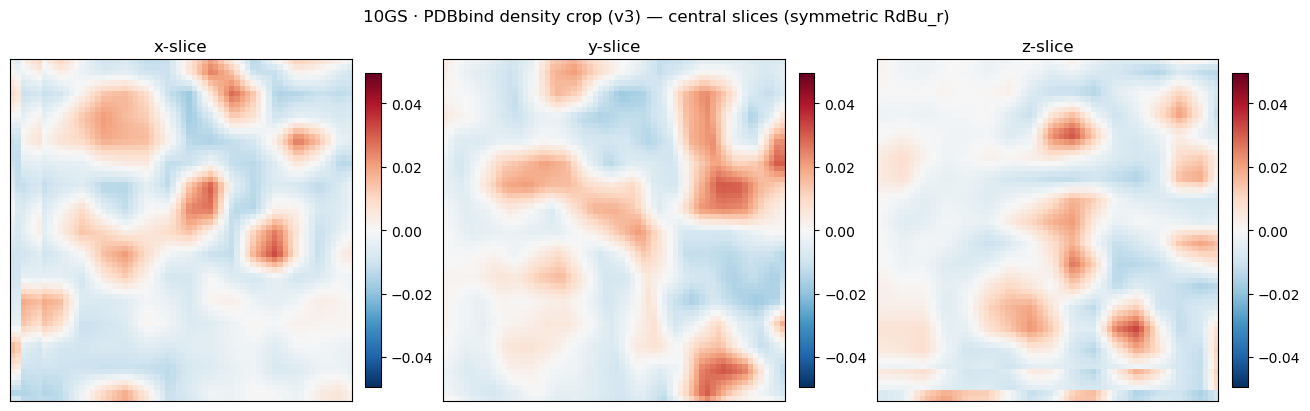

In [8]:
# ── B3 · single example — density crop ───────────────────────────────────────
dv = {"v1": "voxels", "v2": "voxels_v2", "v3": "voxels_v3"}[DENSITY_VERSION]
a = np.load(PDBBIND_DIR / dv / "density" / f"{PDBBIND_PDB.lower()}.npy").astype(np.float32)
print(f"{DENSITY_VERSION} crop {a.shape}  range [{a.min():+.3f}, {a.max():+.3f}]  mean {a.mean():+.4f}  std {a.std():.4f}")

def take_slice(vol, axis, off=0):
    i = vol.shape[-1] // 2 + off
    return vol[i] if axis == "x" else vol[:, i] if axis == "y" else vol[:, :, i]

vmax = max(abs(a.min()), abs(a.max()), 1e-6)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
for ax, axis in zip(axes, ["x", "y", "z"]):
    im = ax.imshow(take_slice(a, axis).T, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{axis}-slice"); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"{PDBBIND_PDB.upper()} · PDBbind density crop ({DENSITY_VERSION}) — central slices (symmetric RdBu_r)")
plt.show()

In [9]:
# ── B4 · NGLView surface (optional) ──────────────────────────────────────────
nglview_surface(*pb_ngl)

NGLWidget()

## Notes

* Both parts render in one pass — Part A (CrossDocked, `CROSSDOCKED_PDB`) then Part B (PDBbind, `PDBBIND_PDB`); no dataset toggle.
* **CrossDocked density** needs a downloaded 2Fo-Fc CCP4 (`notebook/data/{pid}.ccp4`) — currently only `14gs`; other PDBs print a note in A3 but stats + structure still work. **PDBbind density** is the stored crop (`voxels_v{1,2,3}`); set `DENSITY_VERSION` to compare normalizations (see `01c_density_distribution`).
* Atom coords: CrossDocked from `data_*.pt` (model frame); PDBbind parsed from pocket `.pdb` (heavy only) + ligand `.sdf`.
* Per-part vars are namespaced (`cd_*` / `pb_*`); `structure_view` / `nglview_surface` are shared. 3D views use plotly (`notebook_connected` — interactive in Jupyter, no browser launch); NGLView is guarded so execution never fails.